# CSCI 447/547 Hackathon 0: scikit-learn (sklearn)

This notebook is designed to be started during class and continued as a take-home activity

## How to use hackathon notebooks:

If the topic covered in a hackathon is new to you, work through the cells in order and read the explanation before running each code cell. You do not need to understand every detail of the hackathon on the first pass, instead, focus on the approach we take:

1. **Look at the data**
2. **Separate inputs from the target we want to predict**
3. **Split the data so we can test whether the model generalizes**
4. **Fit a model using the training data**
5. **Make predictions and evaluate them**
6. **Improve the model carefully <u>without</u> using the final evaluation data to make decisions**

We will work through the salary example together as a class. Pause before important code cells and think about what you expect to see. Please ask Lucy or a TA questions any time a term or line of code is unfamiliar.

After class, continue from wherever you left off. The existing explanations and code will be there to guide you through the process. Complete the marked answer sections, run every cell, and explain what the results mean in language that makes sense for you. Hackathons will not be graded, they are only to help you, and you will get out of them what you put into them.

<h4><span style="color:red">The goal of this notebook is NOT to memorize every function. It is to identify the processes we use in machine learning and be able to reuse them.</span></h4>

# Introduction

`scikit-learn` is a powerful and user-friendly machine learning library for Python. It’s like a toolbox filled with tools that help you build and use machine learning models. The word “scikit” comes from “scientific kit,” emphasizing its focus on scientific and practical applications.

In simple terms, machine learning is a way for computers to learn from data and make predictions or decisions without being explicitly programmed. `scikit-learn` provides a set of tools to make this process easier and more accessible, especially for students who are learning about machine learning.

This notebook demonstrates two **full machine learning workflows** using:
1) Linear regression 
2) Logistic regression (classification)

You may not understand the full details of all of this right now.  That's ok!  The purpose of this notebook is to show the pipelines of two different types of problems, and how `scikit-learn` can help us!

## IN CLASS: Linear Regression Pipeline with Fine-Tuning and Generalization Testing

- Preprocessing (imputation & scaling)
- Linear regression model
- Fine-tuning with GridSearchCV
- Held-out generalization testing

We'll use a synthetic dataset where **Salary depends on Years of Experience**.

**Pause point:** Before running the code, identify the feature, the target, and the kind of prediction this model will make.

In [1]:
## Import Libraries 

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


### Create Synthetic Salary Data

We'll create a dataset of **Years of Experience vs Salary**, with some random noise.


In [2]:
## Create Synthetic Dataset (and have some missing values)

np.random.seed(42)
years = np.linspace(1, 10, 30)
salary = 30000 + 5000 * years + np.random.normal(0, 4000, size=years.shape)

X = pd.DataFrame({'YearsExperience': years})
y = pd.Series(salary, name="Salary")

# Add missing values randomly (10% missing)
missing_indices = np.random.choice(X.index, size=int(0.1 * len(X)), replace=False)
X.loc[missing_indices, 'YearsExperience'] = np.nan

print("Missing values in dataset:")
print(X.isnull().sum()) # Find the number of missing values

X.head(10)



Missing values in dataset:
YearsExperience    3
dtype: int64


,YearsExperience
0,NaN
1,1.310345
2,1.620690
3,1.931034
4,2.241379
5,2.551724
6,2.862069
7,3.172414
8,3.482759
9,3.793103


### Split Data into Train, Fine-Tune, and Generalization Sets

We hold out **20% for generalization**, then split the remaining data into **training (60%)** and **fine-tuning (20%)**.





<img src="attachment:86e0602c-3f93-495b-8e15-dc922bd8eac7.png" width="600">


In [3]:
## Data Splitting

X_temp, X_gen, y_temp, y_gen = train_test_split(X, y, test_size=0.2, random_state=42) #'Test'->'gen' for generalization

X_train, X_fine, y_train, y_fine = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42) #'Validation'->'fine' for fine tuning


### Define the Preprocessing and Pipeline

We'll use:
- **Imputer (mean)** to handle any missing values,
- **StandardScaler** to normalize features,
- **Ridge Regression** for modeling (supports regularization to prevent overfitting)... this is just to give you an idea of hyperparameter tuning!  We'll learn about ridge regression soon :)


In [4]:
## Preprocessing
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[('num', numerical_transformer, X.columns)]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])


### Train the Initial Model and Evaluate Generalization

We'll train the model on the training set and evaluate it on the **held-out generalization set**.


In [5]:
# --- 5. Train Initial Model ---
pipeline.fit(X_train, y_train)

# Evaluate on generalization set
y_pred_initial = pipeline.predict(X_gen)
mse_initial = mean_squared_error(y_gen, y_pred_initial)
r2_initial = r2_score(y_gen, y_pred_initial)

print("Generalization BEFORE Fine-Tuning")
print(f"  Mean Squared Error: {mse_initial:.2f}")
print(f"  R²: {r2_initial:.3f}")


Generalization BEFORE Fine-Tuning
  Mean Squared Error: 10152023.91
  R²: 0.910


## Fine-Tune the Model

We'll fine-tune the model using **GridSearchCV** on the combined training and fine-tuning sets.


In [6]:
X_combined = pd.concat([X_train, X_fine])
y_combined = pd.concat([y_train, y_fine])

param_grid = {
    'regressor__alpha': [0.01, 0.1, 1, 10],  # Ridge regularization strength
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid_search.fit(X_combined, y_combined)

print("Best Parameters After Fine-Tuning:")
grid_search.best_params_


Best Parameters After Fine-Tuning:


{'regressor__alpha': 1}

### Evaluate Generalization AFTER Fine-Tuning


In [7]:
y_pred_after = grid_search.predict(X_gen)
mse_after = mean_squared_error(y_gen, y_pred_after)
r2_after = r2_score(y_gen, y_pred_after)

print("Generalization AFTER Fine-Tuning")
print(f"  Mean Squared Error: {mse_after:.2f}")
print(f"  R²: {r2_after:.3f}")


Generalization AFTER Fine-Tuning
  Mean Squared Error: 8332866.62
  R²: 0.926


### Visualize it!

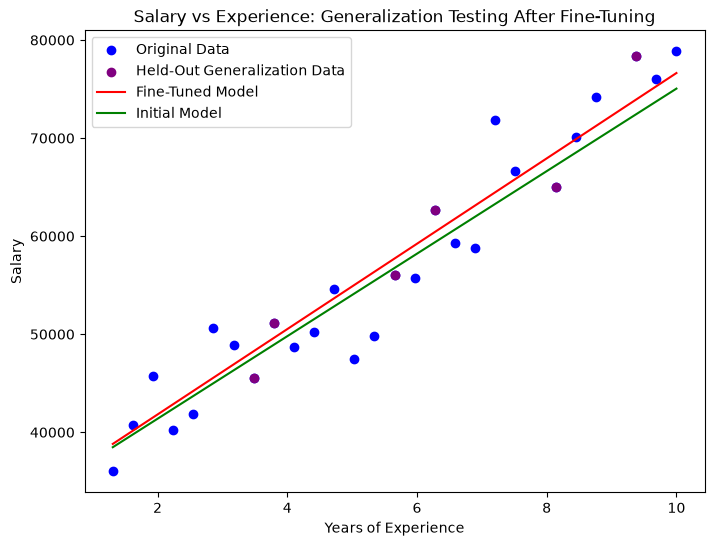

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='blue', label='Original Data')
plt.scatter(X_gen, y_gen, color='purple', label='Held-Out Generalization Data')

x_range = np.linspace(X['YearsExperience'].min(), X['YearsExperience'].max(), 100).reshape(-1, 1)
plt.plot(x_range, grid_search.predict(pd.DataFrame(x_range, columns=['YearsExperience'])), 
         color='red', label='Fine-Tuned Model')

plt.plot(x_range, pipeline.predict(pd.DataFrame(x_range, columns=['YearsExperience'])), 
         color='green', label='Initial Model')

plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Salary vs Experience: Generalization Testing After Fine-Tuning')
plt.legend()
plt.show()

#### What did we do??

- Used a pipeline for preprocessing + regression.

- Performed three-way split: training, fine-tuning, generalization.

- Fine-tuned via Ridge regularization (alpha parameter).

- Tested before and after fine-tuning on a held-out dataset.

## TAKE-HOME EXTENSION: Logistic Regression with Preprocessing, Fine-Tuning, and Generalization Testing

This section applies the same workflow to a classification problem. The explanations and starter code are provided so you can work through it after class.

**Core task:** Run the Iris workflow, compare the initial and fine-tuned models, and explain what the accuracy means for unseen data.

**Optional extension:** Explore how the two-feature visualization differs from the model trained on all four features.

This time we'll try this all with a classification problem.  Again, we'll: 

1. Preprocess numerical features
2. Train a logistic regression classifier
3. Fine-tune the model using hyperparameter search
4. Test **generalization on a held-out dataset**

We'll use the **Iris dataset**, a classic classification problem.

**Pause point:** Before running the code, identify the features, the target, and whether the target is continuous or categorical.

In [9]:
## Import Libraries 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



### Load the Data

We load the Iris dataset and view its structure. The features are numeric, so we'll preprocess them with **imputation (mean)** and **standard scaling**.


In [10]:
## Load Data 
data = load_iris(as_frame=True)
X = data.data
y = data.target

X.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [21]:
y.head() #This corrsponds with the iris 'type' 0, 1, and 2

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

### Create Train, Fine-Tune, and Generalization Test Sets

Again, to properly evaluate generalization, we will **Hold out 20%** of the data for a final generalization test. The we'll split the remaining 80% into **training (60%)** and **fine-tuning (20%)** sets.


In [12]:
## Data Splitting

# the "stratify" parameter keeps the class proportions similar across the random splits.
X_temp, X_gen, y_temp, y_gen = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_fine, y_train, y_fine = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)



In [13]:
## Preprocessing

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[('num', numerical_transformer, X.columns)]
)


### Create and Train the Initial Model

We use a **Logistic Regression** classifier with the preprocessing steps wrapped in a single `Pipeline`.


In [14]:
# Initial Pipeline

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['sepal length (cm)','sepal width (cm)','petal length (cm)', 'petal width (cm)']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all 

### Evaluate Generalization BEFORE Fine-Tuning

Remember... the held-out generalization set was **not used for training**.  
We now measure how well the model generalizes to unseen data.


In [15]:

y_pred_initial = pipeline.predict(X_gen)
acc_initial = accuracy_score(y_gen, y_pred_initial)

print("Generalization BEFORE Fine-Tuning")
print(f"  Accuracy: {acc_initial:.3f}")


Generalization BEFORE Fine-Tuning
  Accuracy: 0.933


### Fine-Tune the Model

We perform **hyperparameter tuning using GridSearchCV** on the **training + fine-tuning sets combined**.  
This simulates updating the model with more recent or expanded data.


In [16]:
X_combined = pd.concat([X_train, X_fine])
y_combined = pd.concat([y_train, y_fine])

param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__l1_ratio': [0], # for L2 regularization
    'classifier__solver': ['lbfgs', 'saga']
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_combined, y_combined)

print("Best Parameters After Fine-Tuning:")
grid_search.best_params_


Best Parameters After Fine-Tuning:


{'classifier__C': 1, 'classifier__l1_ratio': 0, 'classifier__solver': 'lbfgs'}

Again, you probably don't know what's going on here... that's ok!  This is just to show you how we'll tune these 'hyperparameters'.

### Evaluate Generalization AFTER Fine-Tuning

We now evaluate the fine-tuned model on the **same held-out generalization set** to see if generalization improved.


In [17]:
y_pred_after = grid_search.predict(X_gen)
acc_after = accuracy_score(y_gen, y_pred_after)

print("Generalization AFTER Fine-Tuning")
print(f"  Accuracy: {acc_after:.3f}")


Generalization AFTER Fine-Tuning
  Accuracy: 0.933


### Now let's visualize all that: 

In [18]:
# Two-Feature Visualization Model
# The main classifier uses all four Iris measurements. To draw a two-dimensional
# decision-boundary plot, this separate model uses only the two plotted features.
features_vis = ['sepal length (cm)', 'sepal width (cm)']
visualization_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000))
])

visualization_grid = {
    'classifier__C': [0.01, 0.1, 1, 10]
}

grid_search_vis = GridSearchCV(
    visualization_pipeline,
    visualization_grid,
    cv=5,
    scoring='accuracy'
)
grid_search_vis.fit(X_train[features_vis], y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fi

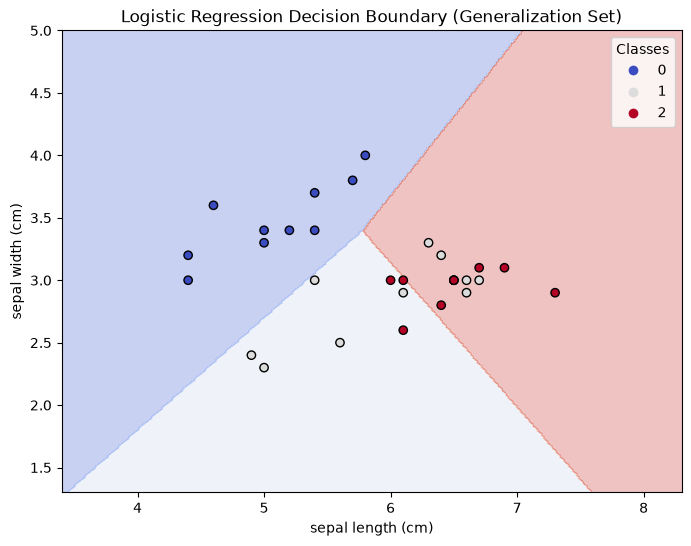

In [19]:

best_pipeline = grid_search_vis.best_estimator_

# Define the features used for visualization
features_vis = ['sepal length (cm)', 'sepal width (cm)']

# Determine min/max from the generalization set
x_min, x_max = X_gen[features_vis[0]].min() - 1, X_gen[features_vis[0]].max() + 1
y_min, y_max = X_gen[features_vis[1]].min() - 1, X_gen[features_vis[1]].max() + 1

# Create the mesh grid
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Convert mesh grid to DataFrame with the same column names
mesh_df = pd.DataFrame(
    np.c_[xx.ravel(), yy.ravel()],
    columns=features_vis
)

# Predict decision regions
Z = best_pipeline.predict(mesh_df)
Z = Z.reshape(xx.shape)

# Plot decision boundary with generalization dataset
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter = plt.scatter(X_gen[features_vis[0]], X_gen[features_vis[1]],
                      c=y_gen, edgecolor='k', cmap=plt.cm.coolwarm)

plt.xlabel(features_vis[0])
plt.ylabel(features_vis[1])
plt.title("Logistic Regression Decision Boundary (Generalization Set)")
plt.legend(*scatter.legend_elements(), title="Classes")
plt.show()

Hey what gives?? We've got an accuracy of 1... but some of these are clearly mismatched??? Well that's becuase we're actually using different models here — one trained on all features (grid_search), one on just two feature (grid_search_vis). So if evaluate accuracy using the same pipeline as this plot we actually get:

In [20]:
y_pred_vis = grid_search_vis.predict(X_gen[features_vis])
acc_vis = accuracy_score(y_gen, y_pred_vis)
print(f"Generalization Accuracy (2D features): {acc_vis:.3f}")


Generalization Accuracy (2D features): 0.733


### Done!

Ok so you might not have understood most of that... and that's ok!  This was just to get an idea of this library.  Hope you had fun!